# 1. Veri Hazırlığı ve Model Kurulumu
## 1. Data Preparation & Model Setup

### 1.1. Hazırlık ve Bağımlılıklar
##### 1.1. Initialization & Dependencies

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from category_encoders import TargetEncoder

# Brand Kit
PRIMARY = '#2C3E50'
SECONDARY = '#2980B9'
ACCENT = '#E74C3C'

sns.set_theme(style='white')
plt.rcParams['axes.titleweight'] = 'bold'
plt.rcParams['axes.titlesize'] = 12

print("Kütüphaneler yüklendi / Libraries loaded")

Kütüphaneler yüklendi / Libraries loaded


### 1.2. Veri Yükleme
##### 1.2. Data Loading

In [2]:
df = pd.read_csv(r"..\01_data\02_processed_data\supply_chain_refined_data.csv", encoding='utf-8-sig')
print(f"Satır / Rows: {df.shape[0]}, Sütun / Columns: {df.shape[1]}")

Satır / Rows: 180516, Sütun / Columns: 43


### 1.3. Veri Filtreleme ve Hedef Değişken
##### 1.3. Data Filtering and Target Variable

In [3]:
# Tahmin edilecek siparişlerin iptal edilmediği varsayılıyor
# Assuming the orders to be predicted are not canceled

df = df[df['delivery_status'] != 'Shipping canceled'].reset_index(drop=True)
print(f"Kalan satır / Remaining rows: {df.shape[0]}")

Kalan satır / Remaining rows: 172762


### 1.4. Özellik Mühendisliği
##### 1.4. Feature Engineering

In [4]:
# Teslimat baskısı - süre azaldıkça çarpan artar
# Delivery pressure - multiplier increases as time decreases
time_factor = 4 / (df['scheduled_days'] + 1)

# Ürün değeri ve miktar riski - pahalı ve hacimli ürün + kısa süre
# Product value and quantity risk - expensive and high-volume products + short timeframe
df['load_risk_score'] = (df['product_price'] * df['item_quantity']) * time_factor

# Zamanlama riski - akşam siparişi + kısa süre
# Timing risk - evening orders + short timeframe
df['temporal_stress'] = (df['order_hour'] > 17).astype(int) * time_factor

# Dominant sütunu çıkar - bilgisi hibrit sütunlara gömüldü
# Drop the dominant column - its information is embedded into hybrid features
X = df.drop(columns=['late_delivery', 'scheduled_days'])
y = df['late_delivery']

print(f"X shape: {X.shape}")
print(f"y dağılımı / y distribution:\n{y.value_counts(normalize=True).round(3)}")

X shape: (172762, 43)
y dağılımı / y distribution:
late_delivery
1    0.573
0    0.427
Name: proportion, dtype: float64


### 1.5. Eğitim / Test Ayrımı
##### 1.5. Train / Test Split

In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"X_train: {X_train.shape}, X_test: {X_test.shape}")
print(f"Train y dağılımı / Train y distribution:\n{y_train.value_counts(normalize=True).round(3)}")
print(f"Test y dağılımı / Test y distribution:\n{y_test.value_counts(normalize=True).round(3)}")

X_train: (138209, 43), X_test: (34553, 43)
Train y dağılımı / Train y distribution:
late_delivery
1    0.573
0    0.427
Name: proportion, dtype: float64
Test y dağılımı / Test y distribution:
late_delivery
1    0.573
0    0.427
Name: proportion, dtype: float64


### 1.6. Ön İşleme ve Model Kurulumu
##### 1.6. Preprocessing and Model Setup

In [6]:
# Sütun grupları
# Column groups
numeric_features = [
    'product_price', 'item_quantity', 'sales',
    'discount_rate', 'load_risk_score', 'temporal_stress'
]
categorical_low = ['payment_type', 'customer_segment']
categorical_high = ['order_region', 'order_country']

# Ön işleme
# Preprocessor
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        ('cat_low', OneHotEncoder(handle_unknown='ignore', drop='first'), categorical_low),
        ('cat_high', TargetEncoder(), categorical_high)
    ],
    remainder='passthrough'
)

# Model için final feature listesi
# Final feature list for the model
cols_to_use = numeric_features + categorical_low + categorical_high + [
    'order_day_of_week', 'order_month', 'order_hour', 'is_weekend', 'category_id'
]

X_train_model = X_train[cols_to_use]
X_test_model = X_test[cols_to_use]

print(f"Preprocessor hazır / Preprocessor ready")
print(f"Feature sayısı / Feature count: {len(cols_to_use)}")
print(f"X_train_model: {X_train_model.shape}")

Preprocessor hazır / Preprocessor ready
Feature sayısı / Feature count: 15
X_train_model: (138209, 15)


# 2. Model Eğitimi ve Değerlendirme
## 2. Model Training and Evaluation

### 2.1. Model Eğitimi
##### 2.1. Model Training

In [7]:
models = {
    "Logistic Regression": LogisticRegression(class_weight='balanced', random_state=42, max_iter=1000),
    "Random Forest": RandomForestClassifier(n_estimators=100, max_depth=15, random_state=42, class_weight='balanced'),
    "XGBoost": XGBClassifier(eval_metric='logloss', random_state=42),
    "LightGBM": LGBMClassifier(verbose=-1, random_state=42)
}

results = {}

for name, model in models.items():
    clf = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('classifier', model)
    ])
    
    clf.fit(X_train_model, y_train)
    y_pred = clf.predict(X_test_model)
    
    train_score = clf.score(X_train_model, y_train)
    test_score = clf.score(X_test_model, y_test)
    
    print(f"\n--- {name} Sonuçları / Results ---")
    print(classification_report(y_test, y_pred))
    print(f"Train Accuracy: {train_score:.4f} | Test Accuracy: {test_score:.4f}")
    print(f"Gap: %{(train_score - test_score)*100:.2f}")
    
    results[name] = clf


--- Logistic Regression Sonuçları / Results ---
              precision    recall  f1-score   support

           0       0.52      0.76      0.62     14757
           1       0.73      0.48      0.58     19796

    accuracy                           0.60     34553
   macro avg       0.62      0.62      0.60     34553
weighted avg       0.64      0.60      0.60     34553

Train Accuracy: 0.6023 | Test Accuracy: 0.5990
Gap: %0.33

--- Random Forest Sonuçları / Results ---
              precision    recall  f1-score   support

           0       0.62      0.90      0.74     14757
           1       0.88      0.60      0.71     19796

    accuracy                           0.72     34553
   macro avg       0.75      0.75      0.72     34553
weighted avg       0.77      0.72      0.72     34553

Train Accuracy: 0.7565 | Test Accuracy: 0.7243
Gap: %3.22

--- XGBoost Sonuçları / Results ---
              precision    recall  f1-score   support

           0       0.63      0.86      0.73   

### 2.2. ROC-AUC Skorları
##### 2.2. ROC-AUC Scores

In [8]:
for name, clf in results.items():
    y_prob = clf.predict_proba(X_test_model)[:, 1]
    roc_auc = roc_auc_score(y_test, y_prob)
    print(f"{name} ROC-AUC: {roc_auc:.4f}")

Logistic Regression ROC-AUC: 0.6656
Random Forest ROC-AUC: 0.7997
XGBoost ROC-AUC: 0.8005
LightGBM ROC-AUC: 0.7963


### 2.3. Özellik Önem Dereceleri
##### 2.3. Feature Importance

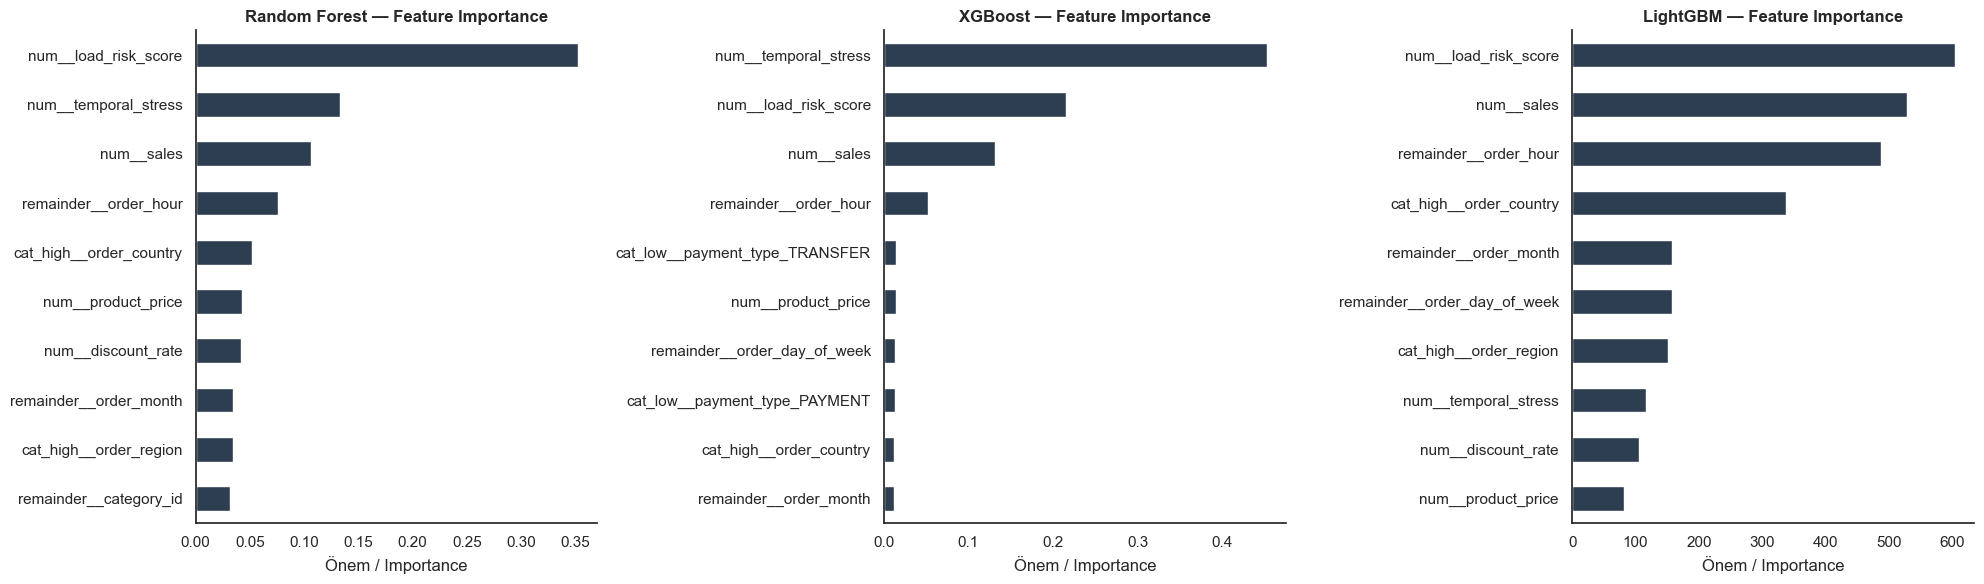

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

for ax, name in zip(axes, ['Random Forest', 'XGBoost', 'LightGBM']):
    model = results[name].named_steps['classifier']
    feature_names = results[name].named_steps['preprocessor'].get_feature_names_out()
    
    importances = pd.Series(model.feature_importances_, index=feature_names)\
        .sort_values(ascending=True).tail(10)
    
    importances.plot(kind='barh', ax=ax, color=PRIMARY)
    ax.set_title(f'{name} — Feature Importance')
    ax.set_xlabel('Önem / Importance')
    sns.despine(ax=ax)

plt.tight_layout()
plt.show()

# 3. Threshold Optimizasyonu ve Final Model
## 3. Threshold Optimization and Final Model

### 3.1. Threshold Analizi
##### 3.1. Threshold Analysis

In [10]:
# LightGBM seçildi: en düşük overfitting gap (%0.26), en dengeli model
# LightGBM selected: lowest overfitting gap (0.26%), the most balanced model
y_prob_lgbm = results['LightGBM'].predict_proba(X_test_model)[:, 1]

# Hedef: gecikecek siparişi kaçırmamak - recall(1) kritik
# Goal: Not to miss delayed orders - recall(1) is critical
thresholds = [0.3, 0.35, 0.4, 0.45, 0.5]

for threshold in thresholds:
    y_pred_thresh = (y_prob_lgbm >= threshold).astype(int)
    report = classification_report(y_test, y_pred_thresh, output_dict=True)
    recall_1 = report['1']['recall']
    precision_1 = report['1']['precision']
    accuracy = report['accuracy']
    print(f"Threshold: {threshold} | Recall(1): {recall_1:.3f} | Precision(1): {precision_1:.3f} | Accuracy: {accuracy:.3f}")

Threshold: 0.3 | Recall(1): 0.998 | Precision(1): 0.591 | Accuracy: 0.604
Threshold: 0.35 | Recall(1): 0.988 | Precision(1): 0.598 | Accuracy: 0.612
Threshold: 0.4 | Recall(1): 0.815 | Precision(1): 0.688 | Accuracy: 0.682
Threshold: 0.45 | Recall(1): 0.618 | Precision(1): 0.864 | Accuracy: 0.725
Threshold: 0.5 | Recall(1): 0.598 | Precision(1): 0.886 | Accuracy: 0.725


### 3.2. Final Model Sonuçları
##### 3.2. Final Model Results

Final Model: LightGBM | Threshold: 0.40
              precision    recall  f1-score   support

           0       0.67      0.50      0.58     14757
           1       0.69      0.82      0.75     19796

    accuracy                           0.68     34553
   macro avg       0.68      0.66      0.66     34553
weighted avg       0.68      0.68      0.67     34553



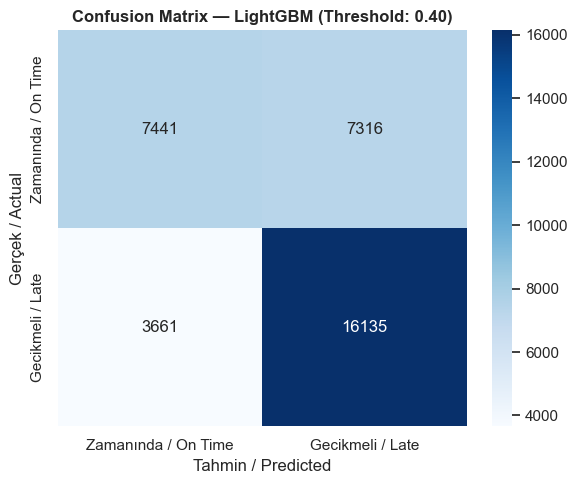

In [11]:
# Threshold 0.40: Recall(1) 0.82, kabul edilebilir precision trade-off
# Threshold 0.40: Recall(1) 0.82, acceptable precision trade-off
y_pred_final = (y_prob_lgbm >= 0.40).astype(int)

print("Final Model: LightGBM | Threshold: 0.40")
print("="*50)
print(classification_report(y_test, y_pred_final))

cm = confusion_matrix(y_test, y_pred_final)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Zamanında / On Time', 'Gecikmeli / Late'],
            yticklabels=['Zamanında / On Time', 'Gecikmeli / Late'])
plt.title('Confusion Matrix — LightGBM (Threshold: 0.40)')
plt.xlabel('Tahmin / Predicted')
plt.ylabel('Gerçek / Actual')
plt.tight_layout()
plt.show()

### 3.3. Model Kaydı
##### 3.3. Model Export

In [12]:
model_path = r"..\04_models\lightgbm_late_delivery.pkl"
joblib.dump(results['LightGBM'], model_path)

print(f"Model kaydedildi / Model saved: {model_path}")
print(f"Model: LightGBM | Threshold: 0.40")
print(f"Test Accuracy: 0.7254 | Recall(1): 0.82")

Model kaydedildi / Model saved: ..\04_models\lightgbm_late_delivery.pkl
Model: LightGBM | Threshold: 0.40
Test Accuracy: 0.7254 | Recall(1): 0.82
